# Uber Trip Analysis

## Introduction

Uber is one of the widely used ride-hailing services in urban areas. Analyzing Uber trip data can help us understand travel patterns, peak demand periods, and the geographical distribution of trips.

In this project, we analyze Uber trip data from New York City to identify important patterns in Uber usage. The analysis focuses on trip timings, days of the week, months, Uber bases, and pickup locations.

The insights obtained from this analysis can help understand customer demand and identify the busiest periods and locations.

## Objectives

The main objectives of this project are:

- To understand the structure and characteristics of the Uber trip dataset.
- To analyze the number of Uber trips during different hours of the day.
- To identify the busiest days of the week.
- To compare the number of trips across different months.
- To analyze the distribution of trips among different Uber bases.
- To visualize the geographical distribution of Uber pickup locations.
- To identify useful patterns and insights from the dataset.

## Dataset Description

The dataset contains Uber trip records from New York City.

The main columns used in the analysis are:

- **Date/Time** – Date and time when the Uber trip was recorded.
- **Lat** – Latitude of the pickup location.
- **Lon** – Longitude of the pickup location.
- **Base** – Uber base associated with the trip.
- **Day** – Day of the month.
- **DayOfWeek** – Day of the week on which the trip occurred.
- **Month** – Month in which the trip occurred.
- **Hour** – Hour of the day extracted from the Date/Time column.

These variables are used to analyze temporal and geographical patterns in Uber trips.

## Libraries Used

The following Python libraries are used for data analysis and visualization:

- **Pandas** – Used for data loading, manipulation, cleaning, and analysis.
- **NumPy** – Used for numerical operations.
- **Matplotlib** – Used to create data visualizations.
- **Seaborn** – Used for statistical data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Load One CSV File

The Uber dataset contains multiple CSV files corresponding to different months. Initially, one CSV file, April 2014 data, is loaded to understand the structure and contents of the dataset.

Loading one file first helps verify the columns, data types, and overall structure before performing the complete analysis.

In [ ]:
import pandas as pd
df = pd.read_csv("uber-raw-data-apr14.csv")
df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [3]:
df.shape

(564516, 4)

In [4]:
df.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='str')

In [5]:
df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


## 2. Understand the Dataset

The dataset is explored to understand its size, columns, data types, statistical information, and missing values.

The main variables include Date/Time, latitude, longitude, and Uber base. This initial exploration helps determine the type of analysis that can be performed on the dataset.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  str    
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  str    
dtypes: float64(2), str(2)
memory usage: 29.9 MB


In [7]:
df.describe()

,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


In [8]:
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

## 3. Convert Date/Time

The Date/Time column is converted from a text format into a proper datetime format.

This conversion allows us to extract useful time-based information such as hour, day, day of the week, and month, which are important for analyzing Uber trip patterns.

In [9]:
df["Date/Time"] = pd.to_datetime(df["Date/Time"])

In [10]:
df.dtypes

Date/Time    datetime64[us]
Lat                 float64
Lon                 float64
Base                    str
dtype: object

## 4. Create Useful Time Columns

Additional time-related columns are created from the Date/Time column.

The following features are extracted:

- **Hour** – Represents the hour of the day when the trip occurred.
- **Day** – Represents the day of the month.
- **DayOfWeek** – Represents the day of the week.
- **Month** – Represents the month of the trip.

These features make it easier to analyze Uber demand according to different time periods.

In [11]:
df["Hour"] = df["Date/Time"].dt.hour

In [12]:
df["Day"] = df["Date/Time"].dt.day

In [13]:
df["DayOfWeek"] = df["Date/Time"].dt.day_name()

In [14]:
df["Month"] = df["Date/Time"].dt.month_name()

In [15]:
df.head()

,Date/Time,Lat,Lon,Base,Hour,Day,DayOfWeek,Month
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,Tuesday,April
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,Tuesday,April
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,Tuesday,April
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,Tuesday,April
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,Tuesday,April


Check duplicate records

## 5. Remove Duplicate Records

The dataset is checked for duplicate records to ensure that the same trip is not counted more than once.

Duplicate records are removed where necessary. This helps improve the accuracy and reliability of the analysis.

In [16]:
df.duplicated().sum()

np.int64(7749)

In [17]:
df = df.drop_duplicates()

In [18]:
print("Rows before:", len(df))
df = df.drop_duplicates()
print("Rows after:", len(df))

Rows before: 556767
Rows after: 556767


## 6. Analyze Uber Trips by Hour

Uber trips are grouped according to the hour of the day.

The hourly trip counts are visualized to identify periods of high and low Uber demand. This analysis helps determine the busiest hours and understand daily travel patterns

In [19]:
hourly_trips = df["Hour"].value_counts().sort_index()
hourly_trips

Hour
0     11716
1      7620
2      4849
3      4938
4      5965
5      9302
6     18224
7     24624
8     22577
9     17758
10    17660
11    18545
12    19179
13    22329
14    26851
15    34835
16    41408
17    44888
18    42439
19    38380
20    35729
21    36427
22    30189
23    20335
Name: count, dtype: int64

## Uber Trips By Hour Bar Graph

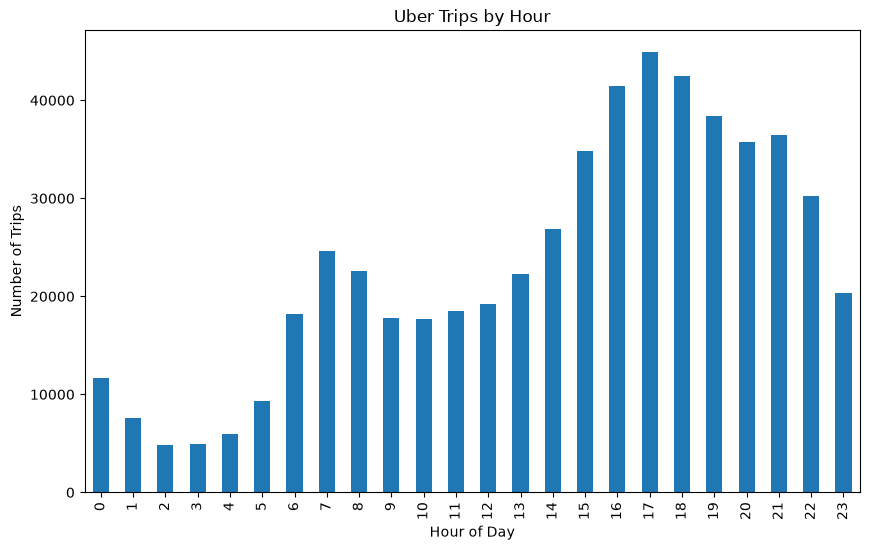

In [20]:
plt.figure(figsize=(10,6))
hourly_trips.plot(kind="bar")
plt.title("Uber Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

## Uber Trips By Hour Line Graph

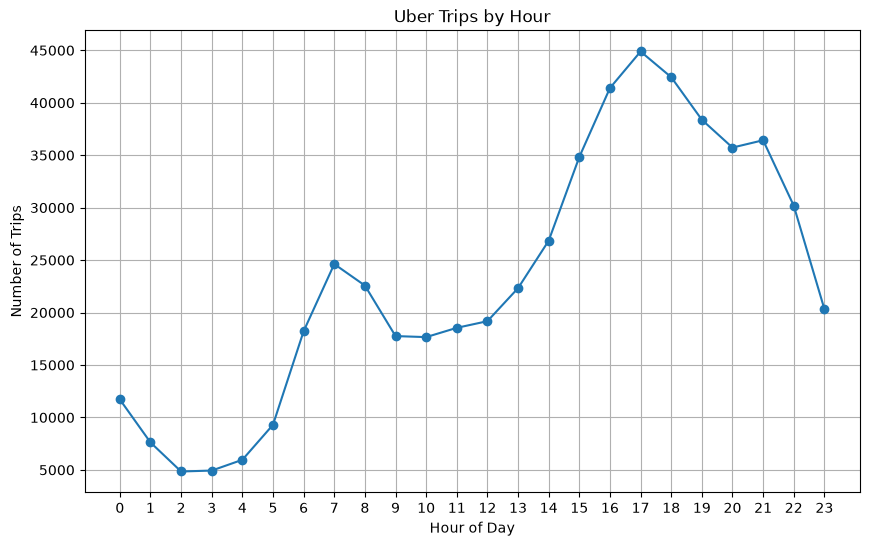

In [21]:
hourly_trips = df["Hour"].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.plot(hourly_trips.index, hourly_trips.values, marker="o")
plt.title("Uber Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.grid()
plt.show()

In [22]:
weekday_trips = df["DayOfWeek"].value_counts()
weekday_trips

DayOfWeek
Wednesday    107120
Tuesday       89957
Friday        88985
Thursday      83954
Saturday      76152
Monday        60075
Sunday        50524
Name: count, dtype: int64

In [23]:
days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_trips = df["DayOfWeek"].value_counts().reindex(days)

## Uber Trips By Day Of week

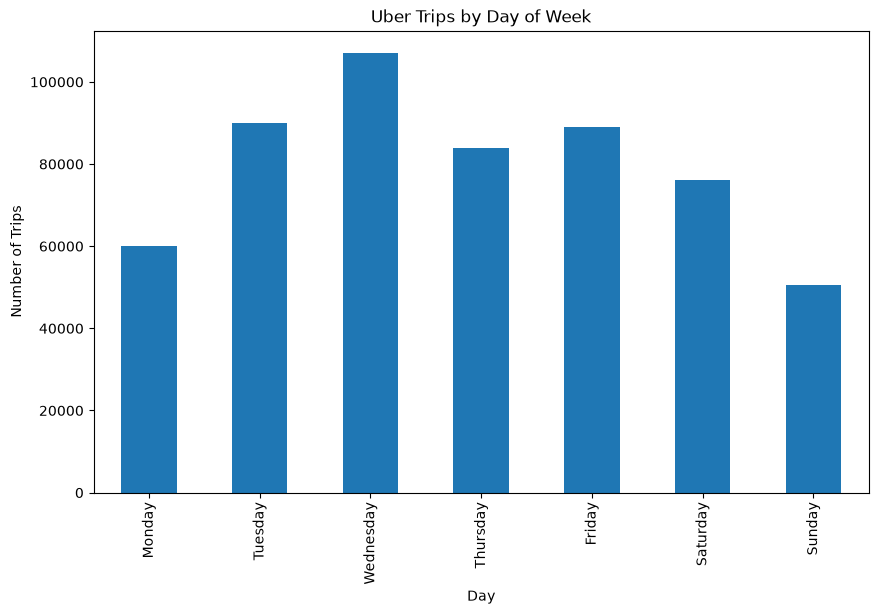

In [24]:
plt.figure(figsize=(10,6))
weekday_trips.plot(kind="bar")
plt.title("Uber Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.show()

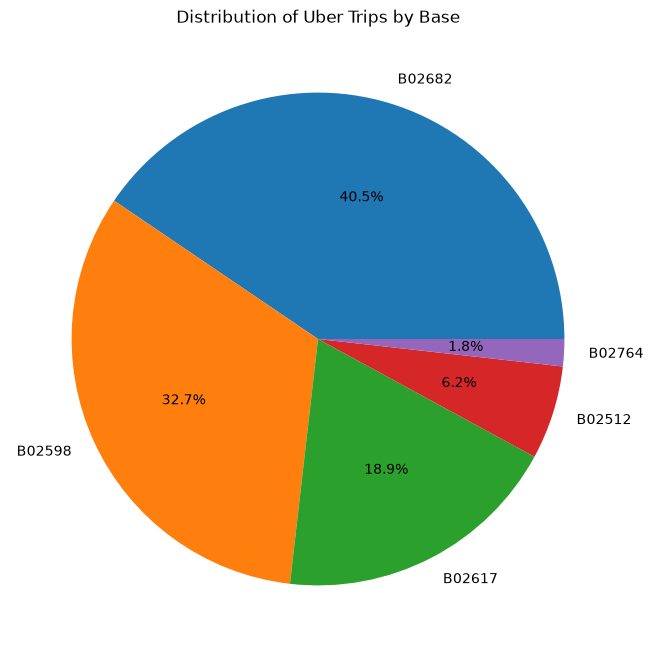

In [25]:
base_trips = df["Base"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(base_trips.values, labels=base_trips.index, autopct="%1.1f%%")
plt.title("Distribution of Uber Trips by Base")
plt.show()

## 7.Pickup Location Analysis

The latitude and longitude columns are used to analyze the geographical distribution of Uber pickup locations.

A scatter plot is created using longitude on the x-axis and latitude on the y-axis. Each point represents a recorded Uber pickup location.

This visualization helps identify areas where Uber pickups are highly concentrated and areas with relatively fewer pickups.

The analysis provides a geographical understanding of Uber demand and helps identify locations with high pickup activity.

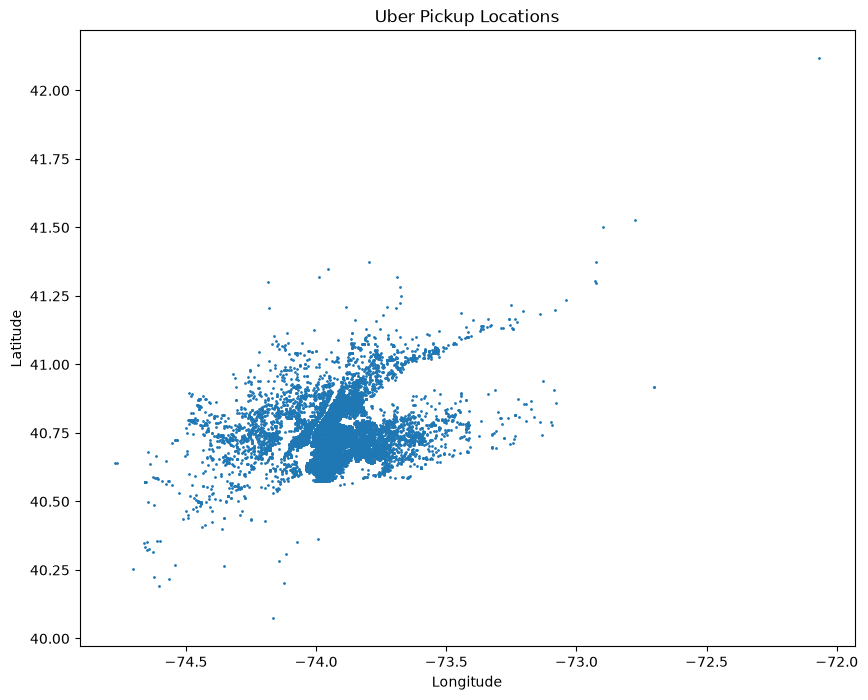

In [26]:
plt.figure(figsize=(10,8))
plt.scatter(df["Lon"], df["Lat"], s=1)
plt.title("Uber Pickup Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 8. Combine April–September Data

The Uber trip datasets from April 2014 to September 2014 are combined into a single dataset.

Since these monthly datasets have a similar structure, they can be concatenated together. Combining the files provides a larger dataset for analyzing Uber trip patterns across multiple months.

In [27]:
file = [r"C:\Users\CH KAVYA\Downloads\Uber_Trip_Analysis\Data\uber-raw-data-apr14.csv",]
dataframes = []

for file in file:
    temp = pd.read_csv(file)
    dataframes.append(temp)
df = pd.concat(dataframes, ignore_index=True)
df.shape

(564516, 4)

## 9. Date and Time Feature Engineering

After combining the monthly datasets, the Date/Time column is converted into datetime format.

The required time-based features such as Day, DayOfWeek, Month, and Hour are created again for the combined dataset.

This ensures that the complete dataset is ready for time-based analysis.

In [28]:
df["Date/Time"] = pd.to_datetime(df["Date/Time"])
df["Hour"] = df["Date/Time"].dt.hour
df["Day"] = df["Date/Time"].dt.day
df["DayOfWeek"] = df["Date/Time"].dt.day_name()
df["Month"] = df["Date/Time"].dt.month_name()

## 10. Busiest Month Analysis

The number of Uber trips is calculated for each month in the combined dataset.

The monthly trip counts are compared to identify the month with the highest Uber trip demand during the analyzed period.

In [29]:
monthly_trips = df["Month"].value_counts()
monthly_trips

Month
April    564516
Name: count, dtype: int64

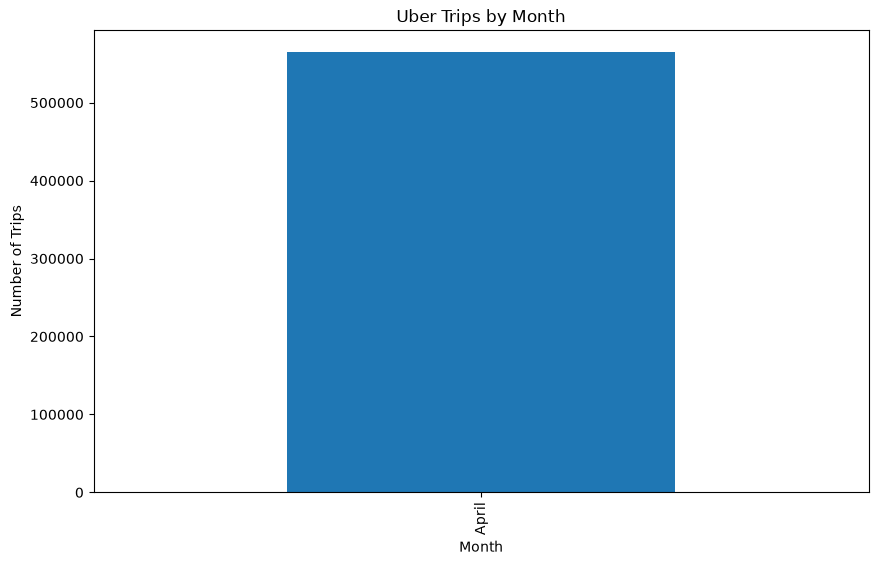

In [30]:
plt.figure(figsize=(10,6))
monthly_trips.plot(kind="bar")
plt.title("Uber Trips by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.show()

## 11. Busiest Hour Analysis

The number of Uber trips is calculated for each hour of the day using the combined dataset.

The hour with the highest number of trips is identified as the busiest hour. This helps understand the time of day when Uber demand is at its highest.

In [31]:
df["Hour"].value_counts().sort_index()

Hour
0     11910
1      7769
2      4935
3      5040
4      6095
5      9476
6     18498
7     24924
8     22843
9     17939
10    17865
11    18774
12    19425
13    22603
14    27190
15    35324
16    42003
17    45475
18    43003
19    38923
20    36244
21    36964
22    30645
23    20649
Name: count, dtype: int64

## 12. Busiest Day Analysis

Uber trips are grouped according to the day of the week.

The trip counts for each day are compared to identify the day with the highest Uber demand. This analysis helps understand differences in trip activity between weekdays and weekends.

In [32]:
df["DayOfWeek"].value_counts()

DayOfWeek
Wednesday    108631
Tuesday       91185
Friday        90303
Thursday      85067
Saturday      77218
Monday        60861
Sunday        51251
Name: count, dtype: int64

In [33]:
df["Base"].value_counts()

Base
B02682    227808
B02598    183263
B02617    108001
B02512     35536
B02764      9908
Name: count, dtype: int64

## 13. Conclusion

The Uber trip dataset was analyzed to understand patterns in Uber usage across different months, hours, days of the week, and Uber bases.

The analysis identified the busiest month, busiest hour, busiest day, and most-used Uber base. Duplicate records were also checked and removed to improve the quality of the analysis.

Overall, the analysis provides useful insights into Uber trip demand and demonstrates how data analysis and visualization can be used to identify meaningful patterns from real-world transportation data.